# **<span style="color:#c8b6ff">Fondations Python, statistiques et données</span>**

Ce notebook est le point de départ de la série.

Il a un objectif simple mais important : construire, pas à pas, les bases mentales et techniques qui servent ensuite pour la régression linéaire, le perceptron, la fonction de perte et la descente de gradient.

L’idée centrale est la suivante : avant de modéliser, il faut savoir lire, structurer et transformer les données.

## Ce que ce notebook couvre

Nous allons progresser dans cet ordre :

1. Python pour les données, à partir d’objets simples
2. Le passage vers NumPy et les tableaux numériques
3. La lecture des données comme vecteurs et matrices
4. Pandas pour les données tabulaires
5. Les statistiques descriptives
6. La visualisation
7. Les relations entre variables
8. La structure d’un jeu de données supervisé
9. Les calculs vectorisés avec NumPy
10. Le lien entre notation mathématique et code
11. Les tenseurs PyTorch
12. Pourquoi PyTorch devient central pour le machine learning
13. Les calculs vectorisés avec PyTorch
14. Une mini synthèse de bout en bout
15. Le bilan et la transition vers la suite

Le fil conducteur sera toujours le même : intuition -> petit exemple -> code -> interprétation -> généralisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

np.set_printoptions(precision=2, suppress=True)
plt.style.use('default')
rng = np.random.default_rng(42)

## 1. **Python pour la donnée: des objets simples aux structures**

Python sait manipuler beaucoup de choses: nombres, textes, booléens, listes.

Pour l’analyse de données, c’est utile au départ, mais les listes Python ne sont pas encore des objets numériques spécialisés. Elles vont vite devenir limitées dès qu’on veut faire des calculs sur beaucoup de valeurs.

In [2]:
# Variables de différents types
age = 29              # entier/int
temperature = 18.5    # decimal/float
ville = 'Paris'       # texte/string
est_ouvert = True     # binaire/bool

# Listes
notes = [12, 15, 9]                     # liste de nombres
matrice_liste = [[1, 2, 3], [4, 5, 6]]  # liste imbriquée

print('Type de age         :', type(age))
print('Type de temperature :', type(temperature))
print('Type de ville       :', type(ville))
print('Type de est_ouvert  :', type(est_ouvert))
print('')
print('Liste de notes           :', notes)
print('Acces à la première note :', notes[0])
print('Addition de listes (concaténation) :', notes + [14]) # cela ajoute 14 à la liste des notes
print("Répétition d'une liste   :", notes * 2) # cela répète la liste des notes deux fois
print('Liste imbriquée          :', matrice_liste)
print('Acces à un élément de la matrice imbriquée :', matrice_liste[1][2])

Type de age         : <class 'int'>
Type de temperature : <class 'float'>
Type de ville       : <class 'str'>
Type de est_ouvert  : <class 'bool'>

Liste de notes           : [12, 15, 9]
Acces à la première note : 12
Addition de listes (concaténation) : [12, 15, 9, 14]
Répétition d'une liste   : [12, 15, 9, 12, 15, 9]
Liste imbriquée          : [[1, 2, 3], [4, 5, 6]]
Acces à un élément de la matrice imbriquée : 6


### Interprétation

Une liste est très flexible, mais son comportement n’est pas celui d’un tableau numérique.

Par exemple, `notes + [14]` ajoute une nouvelle valeur à la liste, alors que dans un calcul scientifique on voudrait souvent additionner élément par élément.

C’est exactement pour cela que NumPy existe: il fournit des structures adaptées aux calculs numériques.

## 2. **Passer à NumPy**

NumPy est la base du calcul scientifique en Python.

Son idée principale est simple : stocker des données numériques dans des tableaux homogènes, puis permettre des opérations rapides et lisibles sur ces tableaux.

Avec NumPy, on peut travailler sur des scalaires, des vecteurs et des matrices avec la même logique.

In [3]:
# Ici on convertit les listes en tableaux numpy
notes_np = np.array(notes, dtype=np.float32)
matrice_np = np.array(matrice_liste, dtype=np.float32)

print('notes_np =', notes_np)
print('dtype    =', notes_np.dtype)
print('shape    =', notes_np.shape) # forme du tableau (nombre de lignes, nombre de colonnes)
print('ndim     =', notes_np.ndim)  # dimension du tableau (1 pour un tableau 1D, 2 pour un tableau 2D, etc.)
print('size     =', notes_np.size)  # nombre total d'éléments dans le tableau (nombre de lignes * nombre de colonnes)
print('')
print('notes_np + 1 =', notes_np + 1) # cela ajoute 1 à chaque élément du tableau des notes
print('notes_np * 2 =', notes_np * 2) # cela multiplie chaque élément du tableau des notes par 2
print('')
print('matrice_np =')
print(matrice_np)
print('shape =', matrice_np.shape)
print('première ligne   =', matrice_np[0]) # accès à la 1ère ligne de la matrice
print('première colonne =', matrice_np[:, 0]) # accès à la 1ère colonne de la matrice (toutes les lignes, 1ère colonne)
print('sous-matrice =')
print(matrice_np[:2, :2]) # accès à une sous-matrice (2 premières lignes, 2 premières colonnes)

notes_np = [12. 15.  9.]
dtype    = float32
shape    = (3,)
ndim     = 1
size     = 3

notes_np + 1 = [13. 16. 10.]
notes_np * 2 = [24. 30. 18.]

matrice_np =
[[1. 2. 3.]
 [4. 5. 6.]]
shape = (2, 3)
première ligne   = [1. 2. 3.]
première colonne = [1. 4.]
sous-matrice =
[[1. 2.]
 [4. 5.]]


### Ce qu’il faut retenir

- `dtype` décrit le type numérique stocké dans le tableau.
- `shape` décrit la forme du tableau.
- `ndim` indique le nombre de dimensions.
- `size` donne le nombre total d’éléments.

Un tableau 1D ressemble à un vecteur.
Un tableau 2D ressemble à une matrice.

### Piège fréquent

`notes_np` a une forme `(3,)` : c’est un vecteur 1D.
Si l’on veut forcer une forme colonne, il faudra utiliser une écriture 2D comme `notes_np.reshape(-1, 1)` ou une sélection du type `X[:, [0]]`.

Exemple :

In [4]:
# Exemple : forcer une forme colonne et différences de sélection de colonnes
notes_np = np.array([12, 15, 9], dtype=np.float32)
print('notes_np =', notes_np)
print('notes_np.shape =', notes_np.shape)  # vecteur 1D (3,)

# Forcer une forme colonne (3,1)
notes_col = notes_np.reshape(-1, 1)
print('notes_col =')
print(notes_col)
print('notes_col.shape =', notes_col.shape)  # colonne 2D (3,1)

notes_np = [12. 15.  9.]
notes_np.shape = (3,)
notes_col =
[[12.]
 [15.]
 [ 9.]]
notes_col.shape = (3, 1)


### Mini-exercice

Sans regarder le résultat, essaye d’anticiper les formes suivantes :

- `X[:, 0]`
- `X[:, [0]]`
- `X.mean(axis=0)`

Le point important n’est pas seulement de savoir faire le calcul, mais de comprendre ce que les dimensions veulent dire.

In [ ]:
X_ex = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
], dtype=np.float32)

print('X_ex.shape         =', X_ex.shape)
print('X_ex[:, 0].shape   =', X_ex[:, 0].shape)   # cela sélectionne la 1ère colonne de X_ex, mais retourne un vecteur 1D (shape (3,) au lieu de (3,1))
print('X_ex[:, [0]].shape =', X_ex[:, [0]].shape) # cela sélectionne la 1ère colonne de X_ex, mais garde la dimension 2D (shape (3,1) au lieu de (3,))
print('X_ex.mean(axis=0)  =', X_ex.mean(axis=0))  # moyenne de chaque colonne (axe 0)
print('X_ex.mean()        =', X_ex.mean())        # moyenne de tous les éléments du tableau

## 3. **Penser en vecteurs et matrices**

C’est une étape centrale.

En machine learning tabulaire, un jeu de données est souvent une matrice :

- chaque **ligne** correspond à une observation
- chaque **colonne** correspond à une feature, c’est-à-dire une variable explicative

Le vocabulaire est important : on ne regarde plus seulement des nombres isolés, on regarde une structure.

In [5]:
X_toy = np.array([
    [35, 2, 40],
    [48, 2, 35],
    [60, 3, 30],
    [72, 3, 25],
], dtype=np.float32)
feature_names_toy = ['surface_m2', 'nb_pieces', 'age_maison']

print('X_toy =')
print(X_toy)
print('')
print('shape =', X_toy.shape)
print('ndim  =', X_toy.ndim)
print('')
print('Première observation (ligne 0) =', X_toy[0])
print('Première feature (colonne 0)   =', X_toy[:, 0])
print('Deux premières lignes, deux premières colonnes =')
print(X_toy[:2, :2])

X_toy =
[[35.  2. 40.]
 [48.  2. 35.]
 [60.  3. 30.]
 [72.  3. 25.]]

shape = (4, 3)
ndim  = 2

Première observation (ligne 0) = [35.  2. 40.]
Première feature (colonne 0)   = [35. 48. 60. 72.]
Deux premières lignes, deux premières colonnes =
[[35.  2.]
 [48.  2.]]


### Lecture mentale de la matrice

Dans `X_toy` :

- la première colonne représente la surface
- la deuxième colonne représente le nombre de pièces
- la troisième colonne représente l’âge du logement

Une ligne complète décrit une observation. C’est exactement ce que l’on retrouvera ensuite pour un vrai dataset d’apprentissage supervisé.

### À retenir

Une observation = une ligne.
Une feature = une colonne.
Un dataset = une matrice de caractéristiques.

## 4. **Pandas et les données tabulaires**

Pandas est très pratique pour lire, nettoyer et explorer des données sous forme de tableau.

La différence essentielle avec NumPy est la suivante :

- NumPy est excellent pour les calculs numériques homogènes
- Pandas est excellent pour manipuler des colonnes nommées, avec éventuellement des types différents dans la même table

En pratique, on explore souvent avec Pandas, puis on convertit en NumPy au moment du calcul.

In [8]:
surface_true = np.array([35, 48, 60, 72, 85, 90, 105, 120], dtype=np.float32)
nb_pieces = np.array([2, 2, 3, 3, 4, 4, 5, 5], dtype=np.int64)
age_maison = np.array([40, 35, 30, 25, 20, 15, 10, 5], dtype=np.int64)
distance_centre_km = np.array([1.2, 1.8, 2.5, 3.0, 4.1, 5.0, 6.2, 7.5], dtype=np.float32)
quartier = ['centre', 'centre', 'est', 'ouest', 'ouest', 'nord', 'sud', 'sud']
etat = ['ancien', 'ancien', 'bon', 'bon', 'très bon', 'très bon', 'excellent', 'excellent']
noise = rng.normal(0, 3, size=8)
prix_k_euros = 30 + 2.5 * surface_true + 7.0 * nb_pieces - 0.7 * age_maison - 3.2 * distance_centre_km + noise

df_raw = pd.DataFrame({
    'surface_m2': surface_true,
    'nb_pieces': nb_pieces,
    'age_maison': age_maison,
    'distance_centre_km': distance_centre_km,
    'quartier': quartier,
    'etat': etat,
    'prix_k_euros': prix_k_euros,
})

df_raw.loc[3, 'surface_m2'] = np.nan
df_raw.loc[4, 'quartier'] = np.nan

print('Valeurs manquantes avant nettoyage :')
print(df_raw.isna().sum())
print()
print('Aperçu du tableau brut :')
display(df_raw.head())

print()
print('Types des colonnes :')
print(df_raw.dtypes)

print()
print('--- Nettoyage simple ---')
df = df_raw.copy()
df['surface_m2'] = df['surface_m2'].fillna(df['surface_m2'].median())
df['quartier'] = df['quartier'].fillna('inconnu')
print('Valeurs manquantes après nettoyage :')
print(df.isna().sum())
print()
print('Aperçu du tableau nettoyé :')
display(df.head())

Valeurs manquantes avant nettoyage :
surface_m2            1
nb_pieces             0
age_maison            0
distance_centre_km    0
quartier              1
etat                  0
prix_k_euros          0
dtype: int64

Aperçu du tableau brut :


,surface_m2,nb_pieces,age_maison,distance_centre_km,quartier,etat,prix_k_euros
0,35.0,2,40,1.2,centre,ancien,100.766252
1,48.0,2,35,1.8,centre,ancien,130.863352
2,60.0,3,30,2.5,est,bon,174.635351
3,NaN,3,25,3.0,ouest,bon,203.750222
4,85.0,4,20,4.1,NaN,très bon,242.825413



Types des colonnes :
surface_m2            float32
nb_pieces               int64
age_maison              int64
distance_centre_km    float32
quartier               object
etat                   object
prix_k_euros          float64
dtype: object

--- Nettoyage simple ---
Valeurs manquantes après nettoyage :
surface_m2            0
nb_pieces             0
age_maison            0
distance_centre_km    0
quartier              0
etat                  0
prix_k_euros          0
dtype: int64

Aperçu du tableau nettoyé :


,surface_m2,nb_pieces,age_maison,distance_centre_km,quartier,etat,prix_k_euros
0,35.0,2,40,1.2,centre,ancien,100.766252
1,48.0,2,35,1.8,centre,ancien,130.863352
2,60.0,3,30,2.5,est,bon,174.635351
3,85.0,3,25,3.0,ouest,bon,203.750222
4,85.0,4,20,4.1,inconnu,très bon,242.825413


### Pourquoi Pandas avant NumPy ?

Parce que les données réelles arrivent rarement déjà prêtes.

Pandas permet de :

- garder les noms de colonnes
- repérer les valeurs manquantes
- sélectionner facilement des sous-ensembles
- effectuer un premier nettoyage lisible

Une fois les colonnes numériques prêtes, on les convertit facilement en tableaux NumPy pour les calculs.

## 5. **Statistiques descriptives**

Avant de modéliser, il faut comprendre ce que les données racontent.

Les statistiques descriptives résument une variable avec quelques nombres clés :

- la moyenne donne un centre de gravité
- la médiane donne une valeur centrale robuste
- le minimum et le maximum donnent les bornes
- la variance et l’écart-type mesurent la dispersion
- les quantiles décrivent la répartition

In [10]:
prix = df['prix_k_euros']

moyenne = prix.mean()
mediane = prix.median()
minimum = prix.min()
maximum = prix.max()
range_ = maximum - minimum
variance = prix.var()
ecart_type = prix.std()
quantiles = prix.quantile([0.25, 0.5, 0.75])

print('Stats descriptives sur le prix :')
print('Moyenne :', round(moyenne, 2))
print('Mediane :', round(mediane, 2))
print('Minimum :', round(minimum, 2))
print('Maximum :', round(maximum, 2))
print('Etendue :', round(range_, 2))
print('Variance :', round(variance, 2))
print('Ecart-type :', round(ecart_type, 2))
print()
print('Quantiles :')
print(quantiles.round(2))
print()
print('Résumé pandas :')
print(prix.describe().round(2))

Stats descriptives sur le prix :
Moyenne : 218.58
Mediane : 223.29
Minimum : 100.77
Maximum : 337.04
Etendue : 236.27
Variance : 6712.13
Ecart-type : 81.93

Quantiles :
0.25    163.69
0.50    223.29
0.75    266.92
Name: prix_k_euros, dtype: float64

Résumé pandas :
count      8.00
mean     218.58
std       81.93
min      100.77
25%      163.69
50%      223.29
75%      266.92
max      337.04
Name: prix_k_euros, dtype: float64


### Comment interpréter ces mesures ?

- Si la moyenne et la médiane sont proches, la distribution est plutôt équilibrée.
- Si l’écart-type est grand, les valeurs sont dispersées.
- Si le minimum et le maximum sont très éloignés, la variable couvre une large plage.
- Les quantiles aident à voir où se situe la majorité des observations.

En data analysis, ces mesures servent à repérer des valeurs atypiques, à comparer des groupes et à préparer les variables avant modélisation.

## 6. **Visualiser pour comprendre**

Un graphique révèle souvent en quelques secondes ce que plusieurs lignes de tableau ne montrent pas immédiatement.

Ici, nous allons utiliser :

- un histogramme pour la distribution
- un boxplot pour les valeurs extrêmes et la dispersion
- un scatter plot pour voir une relation entre deux variables
- une courbe pour visualiser une évolution ordonnée

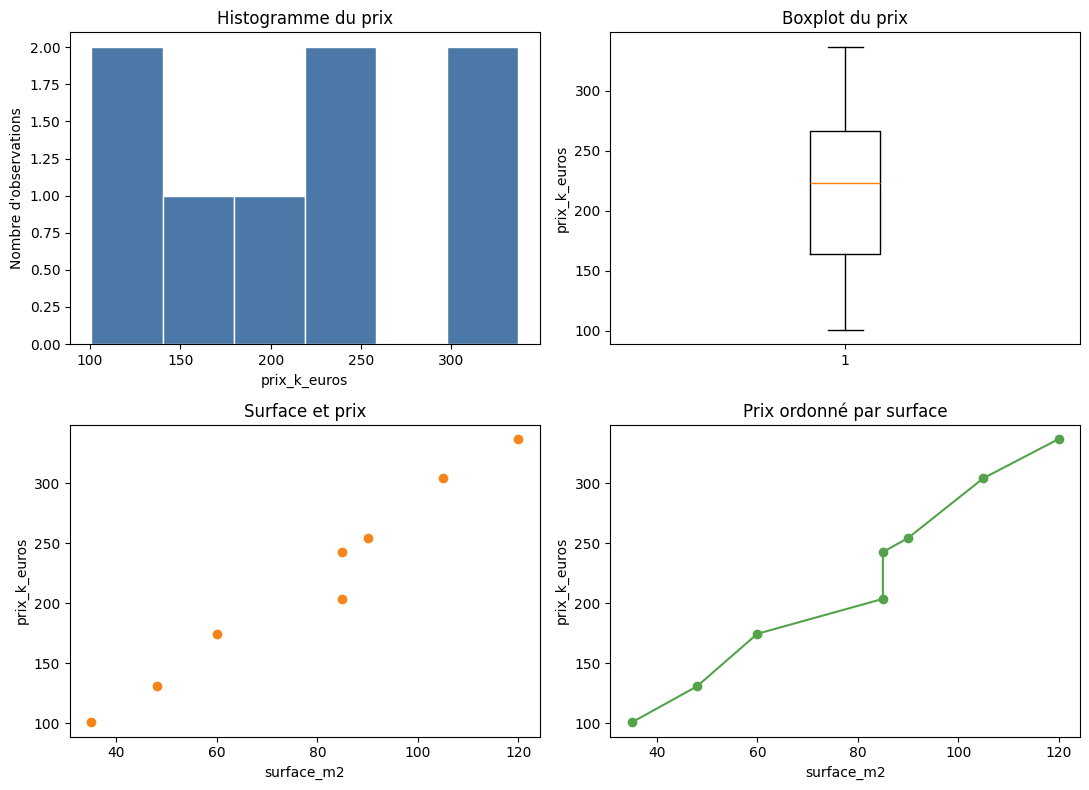

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(prix, bins=6, color='#4C78A8', edgecolor='white')
axes[0, 0].set_title('Histogramme du prix')
axes[0, 0].set_xlabel('prix_k_euros')
axes[0, 0].set_ylabel("Nombre d'observations")

axes[0, 1].boxplot(prix, vert=True)
axes[0, 1].set_title('Boxplot du prix')
axes[0, 1].set_ylabel('prix_k_euros')

axes[1, 0].scatter(df['surface_m2'], prix, color='#F58518')
axes[1, 0].set_title('Surface et prix')
axes[1, 0].set_xlabel('surface_m2')
axes[1, 0].set_ylabel('prix_k_euros')

sorted_df = df.sort_values('surface_m2')
axes[1, 1].plot(sorted_df['surface_m2'], sorted_df['prix_k_euros'], marker='o', color='#54A24B')
axes[1, 1].set_title('Prix ordonné par surface')
axes[1, 1].set_xlabel('surface_m2')
axes[1, 1].set_ylabel('prix_k_euros')

plt.tight_layout()
plt.show()

### Lecture des graphiques

- L’histogramme montre la forme générale de la distribution.
- Le boxplot résume la médiane, les quartiles et les valeurs extrêmes.
- Le scatter plot est essentiel pour voir si deux variables bougent ensemble.
- La courbe ordonnée aide à lire une tendance générale quand les observations sont classées selon une variable.

Le but n’est pas de faire de jolis graphiques. Le but est de mieux comprendre les données.

## 7. **Relation entre variables**

Deux variables peuvent évoluer ensemble.

Pour l’étudier, on regarde notamment :

- la covariance, qui indique si les deux variables bougent dans le même sens ou non
- la corrélation, qui normalise cette idée sur une échelle entre -1 et 1

Une corrélation positive forte signifie qu’une variable augmente souvent quand l’autre augmente.
Une corrélation négative forte signifie qu’une variable augmente souvent quand l’autre diminue.
Une corrélation proche de 0 suggère une relation linéaire faible.

In [13]:
df_corr = df.copy()
df_corr['signal_aleatoire'] = rng.normal(0, 1, size=len(df_corr))

cov_surface_prix = np.cov(df['surface_m2'], df['prix_k_euros'])[0, 1]
corr_surface_prix = df['surface_m2'].corr(df['prix_k_euros'])
corr_aleatoire_prix = df_corr['signal_aleatoire'].corr(df_corr['prix_k_euros'])

print('Covariance surface / prix :', round(cov_surface_prix, 2))
print('Correlation surface / prix :', round(corr_surface_prix, 2))
print('Correlation signal aleatoire / prix :', round(corr_aleatoire_prix, 2))
print()
print('Matrice de correlation :')
display(df_corr[['surface_m2', 'nb_pieces', 'age_maison', 'distance_centre_km', 'prix_k_euros', 'signal_aleatoire']].corr().round(2))

Covariance surface / prix : 2325.04
Correlation surface / prix : 0.99
Correlation signal aleatoire / prix : 0.14

Matrice de correlation :


,surface_m2,nb_pieces,age_maison,distance_centre_km,prix_k_euros,signal_aleatoire
surface_m2,1.00,0.95,-0.98,0.96,0.99,0.24
nb_pieces,0.95,1.00,-0.98,0.97,0.98,0.06
age_maison,-0.98,-0.98,1.00,-0.99,-1.00,-0.09
distance_centre_km,0.96,0.97,-0.99,1.00,0.99,0.06
prix_k_euros,0.99,0.98,-1.00,0.99,1.00,0.14
signal_aleatoire,0.24,0.06,-0.09,0.06,0.14,1.00


### Point conceptuel important

La corrélation n’est pas une preuve de causalité.

Deux variables peuvent être corrélées parce qu’elles dépendent d’un troisième facteur, parce qu’il existe une tendance commune, ou simplement par hasard sur un petit échantillon.

En data analysis comme en machine learning, il faut toujours distinguer :

- ce qui est associé
- ce qui est causal
- ce qui est seulement apparent

## 8. **Features, target et structure d’un dataset supervisé**

En apprentissage supervisé, on sépare souvent :

- `X` : les entrées, c’est-à-dire les features
- `y` : la cible, c’est-à-dire la valeur à prédire

Chaque ligne de `X` représente une observation.
Chaque colonne de `X` représente une feature.
Le vecteur `y` contient une cible par observation.

In [16]:
features = ['surface_m2', 'nb_pieces', 'age_maison', 'distance_centre_km']
target = 'prix_k_euros'

X = df[features].to_numpy(dtype=float)
y = df[target].to_numpy(dtype=float)

print('features =', features)
print('target =', target)
print('X.shape =', X.shape)
print('y.shape =', y.shape)
print('')
print('Première observation X[0] =', X[0])
print('Première feature X[:, 0]  =', X[:, 0])
print('Première cible y[0] =', round(y[0], 2))

features = ['surface_m2', 'nb_pieces', 'age_maison', 'distance_centre_km']
target = prix_k_euros
X.shape = (8, 4)
y.shape = (8,)

Première observation X[0] = [35.   2.  40.   1.2]
Première feature X[:, 0]  = [ 35.  48.  60.  85.  85.  90. 105. 120.]
Première cible y[0] = 100.77


### À quoi sert cette séparation ?

C’est la base de tout futur modèle supervisé.

Le modèle verra `X` et apprendra à produire une estimation de `y`.
Plus tard, c’est exactement cette logique qui servira pour la régression linéaire, puis pour d’autres modèles plus avancés.

## 9. **Calculs vectorisés avec NumPy**

La vectorisation consiste à faire un calcul sur un tableau entier au lieu d’écrire une boucle élément par élément.

C’est plus lisible, souvent plus rapide, et surtout beaucoup plus proche de la manière dont on écrit les modèles mathématiques.

Nous allons voir ici :

- les opérations élément par élément
- les réductions comme `sum` et `mean`
- les calculs par axe
- le broadcasting
- le produit scalaire
- la multiplication matrice-vecteur

In [ ]:
# 1) Opérations elementaires
surface_en_dizaines = X[:, 0] / 10
print('Surface en dizaines de m2 :', np.round(surface_en_dizaines, 2))

# 2) Moyennes par colonne et centrage
column_means = X.mean(axis=0, keepdims=True)
X_centered = X - column_means
print()
print('Moyennes par colonne :', np.round(column_means, 2))
print('Forme de column_means :', column_means.shape)
print('X_centered = X - col_means')
print('Forme de X_centered :', X_centered.shape)
print('Moyennes des colonnes centrées :', np.round(X_centered.mean(axis=0), 10))

# 3) Moyenne par ligne
row_means = X.mean(axis=1)
print()
print('Moyenne par ligne :', np.round(row_means, 2))

# 4) Produit scalaire et score vectorisé
w = np.array([2.5, 7.0, -0.7, -3.2])
scores = X @ w
manual_first_score = sum(x_i * w_i for x_i, w_i in zip(X[0], w))

print()
print('Poids w =', w)
print('Score manuel de la première observation :', round(manual_first_score, 2))
print('Score vectorisé de la première observation :', round(scores[0], 2))
print('Scores pour toutes les observations :', np.round(scores, 2))

Surface en dizaines de m2 : [ 3.5  4.8  6.   8.5  8.5  9.  10.5 12. ]

Moyennes par colonne : [[78.5   3.5  22.5   3.91]]
Forme de column_means : (1, 4)
X_centered = X - col_means
Forme de X_centered : (8, 4)
Moyennes des colonnes centrées : [0. 0. 0. 0.]

Moyenne par ligne : [19.55 21.7  23.88 29.   28.27 28.5  31.55 34.38]

Poids w = [ 2.5  7.  -0.7 -3.2]
Score manuel de la premiere observation : 69.66
Score vectorisé de la premiere observation : 69.66
Scores pour toutes les observations : [ 69.66 103.74 142.   206.4  213.38 226.5  270.66 307.5 ]


### Pourquoi c’est important ?

La plupart des modèles linéaires se résument, au fond, à des combinaisons pondérées de colonnes.

La vectorisation prépare donc directement à comprendre :

- la prédiction d’un modèle linéaire
- les poids associés aux features
- le calcul de lots d’observations en une seule opération

## 10. **De la notation mathématique au code**

Le passage entre mathématiques et code est une compétence fondamentale.

Voici quelques correspondances utiles :

| Notation | Sens | Code NumPy |
|---|---|---|
| `2x` | multiplier un vecteur par un scalaire | `2 * x` |
| `x + z` | addition de deux vecteurs | `x + z` |
| `x · w` | produit scalaire | `x @ w` |
| `Xw` | produit matrice-vecteur | `X @ w` |

Le point clé est de voir que le code n’est pas une autre idée: c’est la même idée écrite dans un langage exécutable.

In [19]:
x = X[0]
z = X[1]

print('x =', x)
print('z =', z)
print('')
print('2 * x =', 2 * x)
print('x + z =', x + z)
print('x @ w =', round(x @ w, 2))
print('X @ w =', np.round(X @ w, 2))
print('')
print('Si on veut un resultat colonne, on peut reshaper w :')
print('w.reshape(-1, 1).shape =', w.reshape(-1, 1).shape)
print('X @ w.reshape(-1, 1) =')
print(np.round(X @ w.reshape(-1, 1), 2))

x = [35.   2.  40.   1.2]
z = [48.   2.  35.   1.8]

2 * x = [70.   4.  80.   2.4]
x + z = [83.  4. 75.  3.]
x @ w = 69.66
X @ w = [ 69.66 103.74 142.   206.4  213.38 226.5  270.66 307.5 ]

Si on veut un resultat colonne, on peut reshaper w :
w.reshape(-1, 1).shape = (4, 1)
X @ w.reshape(-1, 1) =
[[ 69.66]
 [103.74]
 [142.  ]
 [206.4 ]
 [213.38]
 [226.5 ]
 [270.66]
 [307.5 ]]


## 11. **Introduction aux tenseurs PyTorch**

PyTorch utilise des **tenseurs**.

Un tenseur PyTorch ressemble beaucoup à un tableau NumPy :

- même idée de shape
- même idée d’indexation
- mêmes opérations de base

La différence principale est qu’un tenseur s’intègre naturellement dans l’écosystème PyTorch, qui servira plus tard pour l’optimisation, les gradients et l’entraînement des modèles.

In [22]:
X_torch = torch.tensor(X, dtype=torch.float32)
w_torch = torch.tensor(w, dtype=torch.float32)

print('Type  :', type(X_torch))
print('dtype :', X_torch.dtype)
print('shape :', X_torch.shape) # or tuple(X_torch.shape)
print('ndim  :', X_torch.ndim)
print('')
print('Première ligne :', X_torch[0])
print('Première colonne :', X_torch[:, 0])
print('Produit avec un vecteur de poids :', X_torch @ w_torch)
print('')
X_back_to_numpy = X_torch.numpy()
print('Conversion torch -> NumPy OK :', np.allclose(X, X_back_to_numpy))

Type  : <class 'torch.Tensor'>
dtype : torch.float32
shape : torch.Size([8, 4])
ndim  : 2

Première ligne : tensor([35.0000,  2.0000, 40.0000,  1.2000])
Première colonne : tensor([ 35.,  48.,  60.,  85.,  85.,  90., 105., 120.])
Produit avec un vecteur de poids : tensor([ 69.6600, 103.7400, 142.0000, 206.4000, 213.3800, 226.5000, 270.6600,
        307.5000])

Conversion torch -> NumPy OK : True


### Conversion NumPy <-> PyTorch

Sur CPU, la conversion est simple.

- `torch.tensor(...)` crée un tenseur à partir de données existantes
- `torch.from_numpy(...)` convertit un tableau NumPy en tenseur sans copie inutile quand c’est possible
- `.numpy()` permet de revenir vers NumPy

Cette compatibilité est précieuse quand on veut passer progressivement d’une exploration NumPy vers une implémentation PyTorch.

## 12. **Pourquoi PyTorch compte pour la suite**

PyTorch devient central dès qu’on veut aller plus loin que de simples calculs exploratoires.

Il permet de :

- représenter les données sous une forme standard pour le deep learning
- effectuer des calculs efficaces sur des tenseurs
- préparer les étapes futures: modèle, perte, gradient, mise à jour des poids

Autrement dit, apprendre les tenseurs maintenant évite de bloquer plus tard sur la mécanique des modèles.

## 13. **Calculs vectorisés avec PyTorch**

La logique apprise avec NumPy se retrouve presque telle quelle avec PyTorch.

C’est une très bonne nouvelle : une fois que la pensée vectorielle est acquise, le passage de NumPy à PyTorch est naturel.

In [24]:
X_t = torch.tensor(X, dtype=torch.float32)
w_t = torch.tensor(w, dtype=torch.float32)

column_means_t = X_t.mean(dim=0, keepdim=True)
X_centered_t = X_t - column_means_t
scores_t = X_t @ w_t

print('column_means_t.shape =', tuple(column_means_t.shape))
print('X_centered_t.shape =', tuple(X_centered_t.shape))
print('Moyennes des colonnes centrées :', torch.round(X_centered_t.mean(dim=0) * 1000000000) / 1000000000)
print('Scores PyTorch :', torch.round(scores_t * 100) / 100)
print('Première colonne :', X_t[:, 0])
print('Score de la première ligne :', round(float(scores_t[0]), 2))

column_means_t.shape = (1, 4)
X_centered_t.shape = (8, 4)
Moyennes des colonnes centrées : tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 6.0000e-08])
Scores PyTorch : tensor([ 69.6600, 103.7400, 142.0000, 206.4000, 213.3800, 226.5000, 270.6600,
        307.5000])
Première colonne : tensor([ 35.,  48.,  60.,  85.,  85.,  90., 105., 120.])
Score de la première ligne : 69.66


### Lecture pratique

Le plus important ici est moins la syntaxe que l’idée :

- un tableau entier est traité d’un coup
- les réductions résument des colonnes ou des lignes
- le produit matrice-vecteur produit un score par observation

C’est précisément ce qu’on retrouvera dans les implémentations de modèles linéaires.

## 14. **Mini synthèse de bout en bout**

On refait maintenant un petit pipeline complet sur un dataset synthétique plus compact.

L’objectif est de réunir en une seule séquence ce que nous avons vu séparément :

- créer les données
- les inspecter
- calculer des statistiques
- visualiser une relation simple
- construire `X` et `y`
- convertir en NumPy puis en PyTorch
- faire un calcul vectorisé de type `X @ w`

Tableau synthétique :
 surface_m2  nb_pieces  age_maison  prix_k_euros
         30          2          40         114.5
         45          2          30         158.0
         55          3          25         194.8
         70          3          20         235.8
         80          4          15         273.5
         95          4          10         314.8

Résumé statistique :
       surface_m2  nb_pieces  age_maison  prix_k_euros
count        6.00       6.00        6.00          6.00
mean        62.50       3.00       23.33        215.23
std         23.82       0.89       10.80         74.26
min         30.00       2.00       10.00        114.50
25%         47.50       2.25       16.25        167.20
50%         62.50       3.00       22.50        215.30
75%         77.50       3.75       28.75        264.08
max         95.00       4.00       40.00        314.80


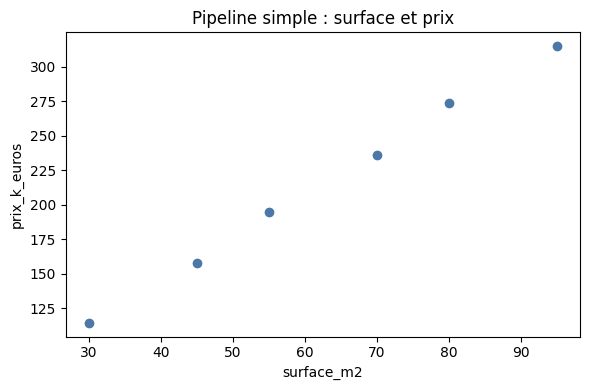

X_pipeline.shape = (6, 3)
y_pipeline.shape = (6,)
Scores NumPy = [ 73.  118.5 154.  197.  232.5 275.5]
Scores PyTorch = tensor([ 73.0000, 118.5000, 154.0000, 197.0000, 232.5000, 275.5000])


In [26]:
df_pipeline = pd.DataFrame({
    'surface_m2': [30, 45, 55, 70, 80, 95],
    'nb_pieces': [2, 2, 3, 3, 4, 4],
    'age_maison': [40, 30, 25, 20, 15, 10],
})
noise_pipeline = np.array([1.5, -0.5, 0.8, -1.2, 1.0, -0.7])
df_pipeline['prix_k_euros'] = 40 + 2.7 * df_pipeline['surface_m2'] + 6.0 * df_pipeline['nb_pieces'] - 0.5 * df_pipeline['age_maison'] + noise_pipeline

print('Tableau synthétique :')
print(df_pipeline.round(2).to_string(index=False))
print()
print('Résumé statistique :')
print(df_pipeline.describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df_pipeline['surface_m2'], df_pipeline['prix_k_euros'], color='#4C78A8')
ax.set_title('Pipeline simple : surface et prix')
ax.set_xlabel('surface_m2')
ax.set_ylabel('prix_k_euros')
plt.tight_layout()
plt.show()

features_pipeline = ['surface_m2', 'nb_pieces', 'age_maison']
target_pipeline = 'prix_k_euros'
X_pipeline = df_pipeline[features_pipeline].to_numpy(dtype=float)
y_pipeline = df_pipeline[target_pipeline].to_numpy(dtype=float)
w_pipeline = np.array([2.7, 6.0, -0.5])

scores_pipeline_np = X_pipeline @ w_pipeline

X_pipeline_t = torch.tensor(X_pipeline, dtype=torch.float32)
w_pipeline_t = torch.tensor(w_pipeline, dtype=torch.float32)
scores_pipeline_t = X_pipeline_t @ w_pipeline_t

print('X_pipeline.shape =', X_pipeline.shape)
print('y_pipeline.shape =', y_pipeline.shape)
print('Scores NumPy =', np.round(scores_pipeline_np, 2))
print('Scores PyTorch =', torch.round(scores_pipeline_t * 100) / 100)

## 15. **Bilan et transition**

À ce stade, tu dois surtout avoir acquis une bonne intuition sur les points suivants :

- un dataset est une structure organisée, pas une simple liste
- une observation est une ligne
- une feature est une colonne
- un target est la valeur à prédire
- les tableaux NumPy permettent de penser en vecteurs et en matrices
- la vectorisation rend les calculs plus naturels et plus efficaces
- les tenseurs PyTorch prolongent cette logique vers le machine learning

La suite naturelle de la série consiste à utiliser ces bases pour construire un modèle linéaire:

- comment une combinaison pondérée produit une prédiction
- comment mesurer l’erreur avec une loss
- comment ajuster les poids avec la descente de gradient
- comment passer d’une écriture mathématique à une implémentation vectorisée

Ce notebook a donc joué son rôle : poser les fondations avant de commencer à apprendre le modèle lui-même.